In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cmcrameri import cm

In [86]:
from emission_process import GlobalEmissionProcessor
import xarray as xr 

ds_eagrid = xr.open_dataset('Emission_grid_all.nc')
cams_path = "CAMS-GLOB-ANT_Glb_0.1x0.1_anthro_nox_v6.2_yearly_2010.nc"
camsds = xr.open_dataset(cams_path)
processor = GlobalEmissionProcessor(camsds, ds_eagrid)

processor.load_cams()
processor.load_eagrid()
processor.build_target_grid()

def extract_original_eagrid(processor, lon_center, lat_center, cams_pix=5):

    size = cams_pix * processor.k
    half = size // 2

    # center in fine grid
    ix = np.argmin(np.abs(processor.eagrid_lon - lon_center))
    iy = np.argmin(np.abs(processor.eagrid_lat - lat_center))

    lon_min = processor.eagrid_lon[ix-half]
    lon_max = processor.eagrid_lon[ix+half]

    lat_min = processor.eagrid_lat[iy-half]
    lat_max = processor.eagrid_lat[iy+half]

    # find indices in original EAGrid
    ix0 = np.searchsorted(processor.eagrid_lon_src, lon_min)
    ix1 = np.searchsorted(processor.eagrid_lon_src, lon_max)

    iy0 = np.searchsorted(processor.eagrid_lat_src, lat_min)
    iy1 = np.searchsorted(processor.eagrid_lat_src, lat_max)


    window = processor.eagrid_emission[iy0:iy1, ix0:ix1]

    return window

0.01
0.01


In [ ]:

# def extract_original_eagrid_overlap(processor, lon_min, lon_max, lat_min, lat_max):

#     R = 6371.0

#     dlon_src = abs(processor.eagrid_lon_src[1] - processor.eagrid_lon_src[0])
#     dlat_src = abs(processor.eagrid_lat_src[1] - processor.eagrid_lat_src[0])

#     ix = np.where((processor.eagrid_lon_src + dlon_src/2 > lon_min) &
#                   (processor.eagrid_lon_src - dlon_src/2 < lon_max))[0]

#     iy = np.where((processor.eagrid_lat_src + dlat_src/2 > lat_min) &
#                   (processor.eagrid_lat_src - dlat_src/2 < lat_max))[0]

#     ix0, ix1 = ix[0], ix[-1] + 1
#     iy0, iy1 = iy[0], iy[-1] + 1

#     lon_src = processor.eagrid_lon_src[ix0:ix1]
#     lat_src = processor.eagrid_lat_src[iy0:iy1]

#     window = processor.eagrid_emission[iy0:iy1, ix0:ix1]

#     exact_areas = np.zeros((len(lat_src), len(lon_src)))
#     weights = np.zeros_like(exact_areas)

#     for j, lat in enumerate(lat_src):

#         s_lat0 = lat - dlat_src/2
#         s_lat1 = lat + dlat_src/2

#         clip_lat0 = max(s_lat0, lat_min)
#         clip_lat1 = min(s_lat1, lat_max)

#         lat_term_clip = np.sin(np.radians(clip_lat1)) - np.sin(np.radians(clip_lat0))
#         lat_term_full = np.sin(np.radians(s_lat1)) - np.sin(np.radians(s_lat0))

#         for i, lon in enumerate(lon_src):

#             s_lon0 = lon - dlon_src/2
#             s_lon1 = lon + dlon_src/2

#             clip_lon0 = max(s_lon0, lon_min)
#             clip_lon1 = min(s_lon1, lon_max)

#             lon_clip = np.radians(clip_lon1 - clip_lon0)
#             lon_full = np.radians(dlon_src)

#             overlap_area = (R**2) * lon_clip * lat_term_clip
#             full_area = (R**2) * lon_full * lat_term_full

#             exact_areas[j, i] = overlap_area

#             if full_area > 0:
#                 weights[j, i] = overlap_area / full_area
                
#     plt.imshow(weights)
#     plt.show()
    
#     weighted_window = window * weights

#     return window, weights, exact_areas, lat_src, lon_src

In [88]:
def get_frame_edges(processor, lon_center, lat_center, cams_pix=5):

    size = cams_pix * processor.k
    half = size // 2

    ix = np.argmin(np.abs(processor.eagrid_lon - lon_center))
    iy = np.argmin(np.abs(processor.eagrid_lat - lat_center))

    dlon = processor.dlon
    dlat = processor.dlat


    lon_min = processor.eagrid_lon[ix-half] - dlon/2
    lon_max = processor.eagrid_lon[ix+half-1] + dlon/2
    lat_min = processor.eagrid_lat[iy-half] - dlat/2
    lat_max = processor.eagrid_lat[iy+half-1] + dlat/2

    print(f'loncenter lon min and lon max :{processor.eagrid_lon[ix]}, {lon_min}, {lon_max}')

    return lon_min, lon_max, lat_min, lat_max

In [ ]:

def plot_testdata(center_lon, center_lat):

    # -------------------------
    # load saved dataset
    # -------------------------
    center_lon_array = np.load("created_data/center_lon_test.npy")
    center_lat_array = np.load("created_data/center_lat_test.npy")

    print(center_lon_array)

    cams_bili_dataset = np.load("created_data/cams_bili_test.npy")
    cams_conserv_dataset = np.load("created_data/cams_conserv_test.npy")
    eagrid_dataset = np.load("created_data/eagrid_dataset_test.npy")

    # -------------------------
    # find nearest center
    # -------------------------
    dist = np.sqrt(
        (center_lon_array - center_lon)**2 +
        (center_lat_array - center_lat)**2
    )

    idx = np.argmin(dist)

    print("Selected index:", idx)
    print("Location:", center_lon_array[idx], center_lat_array[idx])

    # -------------------------
    # extract grids
    # -------------------------
    cams_bili = cams_bili_dataset[idx]
    cams_conserv = cams_conserv_dataset[idx]

    lon = center_lon_array[idx]
    lat = center_lat_array[idx]

    eagrid_before = extract_original_eagrid(processor, lon, lat)
    # calculate exact area and mass (value x area)
    #lon_min, lon_max, lat_min, lat_max = get_frame_edges(processor, lon, lat)
    #eagrid_before_exact, overlap, lat_src_exact, lon_src_exact = extract_original_eagrid_overlap(processor, lon_min, lon_max, lat_min, lat_max)
    #eagrid_before_exact , overlap, lat_src_exact, lon_src_exact  = extract_original_eagrid_overlap(processor, lon, lat)
    eagrid_after = eagrid_dataset[idx]   
    # simple coordinates (50x50 window)
    x = np.arange(cams_bili.shape[1])
    y = np.arange(cams_bili.shape[0])

    x_before = np.arange(eagrid_before.shape[1])
    y_before = np.arange(eagrid_before.shape[0])
    
    # ======================================
    # Calculate conservation (sum of value x area)
    # =======================================

    dlon_src = abs(processor.eagrid_lon_src[1] - processor.eagrid_lon_src[0])
    dlat_src = abs(processor.eagrid_lat_src[1] - processor.eagrid_lat_src[0])

    dlon_dst = abs(processor.eagrid_lon[1] - processor.eagrid_lon[0])
    dlat_dst = abs(processor.eagrid_lat[1] - processor.eagrid_lat[0])

    # source indices again
    ix = np.argmin(np.abs(processor.eagrid_lon - lon))
    iy = np.argmin(np.abs(processor.eagrid_lat - lat))

    size = 5 * processor.k
    half = size // 2

    lon_min = processor.eagrid_lon[ix-half]
    lon_max = processor.eagrid_lon[ix+half]
    lat_min = processor.eagrid_lat[iy-half]
    lat_max = processor.eagrid_lat[iy+half]

    ix0 = np.searchsorted(processor.eagrid_lon_src, lon_min)
    ix1 = np.searchsorted(processor.eagrid_lon_src, lon_max)
    iy0 = np.searchsorted(processor.eagrid_lat_src, lat_min)
    iy1 = np.searchsorted(processor.eagrid_lat_src, lat_max)

    lat_src = processor.eagrid_lat_src[iy0:iy1]
    lat_dst = processor.eagrid_lat[iy-half:iy+half]

    area_src_lat = processor.gridcell_area(lat_src, dlon_src, dlat_src)
    area_dst_lat = processor.gridcell_area(lat_dst, dlon_dst, dlat_dst)

    area_src = np.repeat(area_src_lat[:, None], eagrid_before.shape[1], axis=1)
    area_dst = np.repeat(area_dst_lat[:, None], eagrid_after.shape[1], axis=1)

    before_mass = np.sum(eagrid_before * area_src)
    after_mass  = np.sum(eagrid_after * area_dst)

    before_area = np.sum(area_src)
    after_area  = np.sum(area_dst)

    print("FRAME CONSERVATION CHECK")
    print("mass before:", before_mass)
    print("mass after :", after_mass)
    print("relative error:", abs(after_mass-before_mass)/before_mass)

    print("")

    print("AREA CHECK")
    print("area before:", before_area)
    print("area after :", after_area)
    print("area ratio :", after_area/before_area)

    # # -------------------------------------------------------
    # # ... inside your plot_testdata function ...

    # # 1. Get the target frame bounds
    # lon_min, lon_max, lat_min, lat_max = get_frame_edges(processor, lon, lat)

    # # 2. Extract source window and the ACTUAL area of each cell's contribution to that window
    # # weighted_window, weights, exact_areas, lat_src, lon_src
    # eagrid_before_exact, weight ,area_src_exact, lat_src_exact, lon_src_exact = \
    #     extract_original_eagrid_overlap(processor, lon_min, lon_max, lat_min, lat_max)

    # # 3. Calculate mass (Flux * Area)
    # # Assuming eagrid_emission is a flux (e.g., kg/m2/s)
    # before_mass_exact = np.sum(eagrid_before_exact * area_src_exact)

    # before_area_exact = np.sum(area_src_exact)

    # # 4. Calculate Destination Mass
    # # Ensure your processor.gridcell_area uses the same R^2 * delta_lon * delta_sin_lat logic
    # #dlon_dst = abs(processor.eagrid_lon[1] - processor.eagrid_lon[0])
    # #dlat_dst = abs(processor.eagrid_lat[1] - processor.eagrid_lat[0])
    # #lat_dst_centers = processor.eagrid_lat[iy-half:iy+half]

    # # Calculate dst areas using the same spherical logic
    # #dst_areas_lat = processor.gridcell_area(lat_dst_centers, dlon_dst, dlat_dst) 
    # # Note: If processor.gridcell_area returns area in m2, this is perfect.
    # #area_dst = np.repeat(dst_areas_lat[:, None], eagrid_after.shape[1], axis=1)

    # #after_mass = np.sum(eagrid_after * area_dst)
    # #after_area = np.sum(area_dst)
    # print('')
    # print('CORRECTED conservation check')
    
    # print(f"Corrected Area Ratio: {after_area/before_area_exact}")
    # print("FRAME CONSERVATION CHECK")
    # print("mass before:", before_mass_exact)
    # print("mass after :", after_mass)
    # print(f"Corrected Mass Error: {abs(after_mass - before_mass_exact)/before_mass_exact}")
    
    # # -----------------------------------------------------
    # # conservation check with exact frame area
    # area_src_lat_exact = processor.gridcell_area(lat_src_exact, dlon_src, dlat_src)
    # area_src_exact = np.repeat(area_src_lat_exact[:,None], len(lon_src_exact), axis=1)
    # area_src_exact *= overlap

    # before_area_exact = np.sum(area_src_exact)
    # before_mass_exact = np.sum(eagrid_before_exact * area_src_exact)

    # print('\nconservation check with the exact frame area')
    # print("FRAME CONSERVATION CHECK")
    # print("mass before:", before_mass_exact)
    # print("mass after :", after_mass)
    # print("relative error:", abs(after_mass-before_mass_exact)/before_mass_exact)

    # print('')
    
    # print("AREA CHECK")
    # print("area before:", before_area_exact)
    # print("area after :", after_area)
    # print("area ratio :", after_area/before_area_exact)

    # ================================
    # plot
    # ================================
    cmap = cm.roma_r
    norm = mcolors.Normalize(vmin=2.5, vmax=6.5)

    # =====================================================
    # CAMS before / after
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    ax = axes[0]
    sc = ax.pcolormesh(
        x, y, np.log10(cams_conserv),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('conserv', fontsize=7)

    ax.set_title('cams conserv', fontsize=10)


    ax = axes[1]
    sc = ax.pcolormesh(
        x, y, np.log10(cams_bili),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('cams bilinear', fontsize=7)

    ax.set_title('cams bilinear', fontsize=10)

    # plt.title('CAMS')
    plt.tight_layout()
    plt.show()

    # =====================================================
    # EAGrid before / after
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    ax = axes[0]
    sc = ax.pcolormesh(
        x_before, y_before, np.log10(eagrid_before),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('before', fontsize=7)

    ax.set_title('Before', fontsize=10)


    ax = axes[1]
    sc = ax.pcolormesh(
        x, y, np.log10(eagrid_after),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('after', fontsize=7)

    ax.set_title('After', fontsize=10)

    # plt.title('EAGrid')
    plt.tight_layout()
    plt.show()

[129.725 129.725 129.825 ... 145.125 145.125 145.125]
Selected index: 253
Location: 131.32499999999953 31.950000000000113
FRAME CONSERVATION CHECK
mass before: 9208380.679907575
mass after : 9187238.63852041
relative error: 0.0022959564902976155

AREA CHECK
area before: 2621.634840646186
area after : 2623.2576
area ratio : 1.000618975491182
loncenter lon min and lon max :131.3249969482422, 131.02499389648438, 131.614990234375


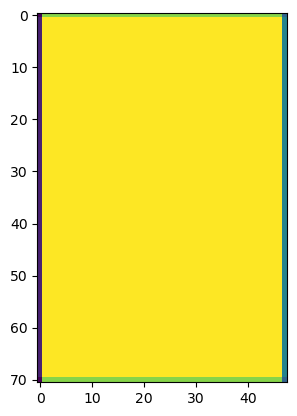


CORRECTED conservation check
Corrected Area Ratio: 0.7186116503701508
FRAME CONSERVATION CHECK
mass before: 10662965.807399133
mass after : 9187238.63852041
Corrected Mass Error: 0.13839743984311587


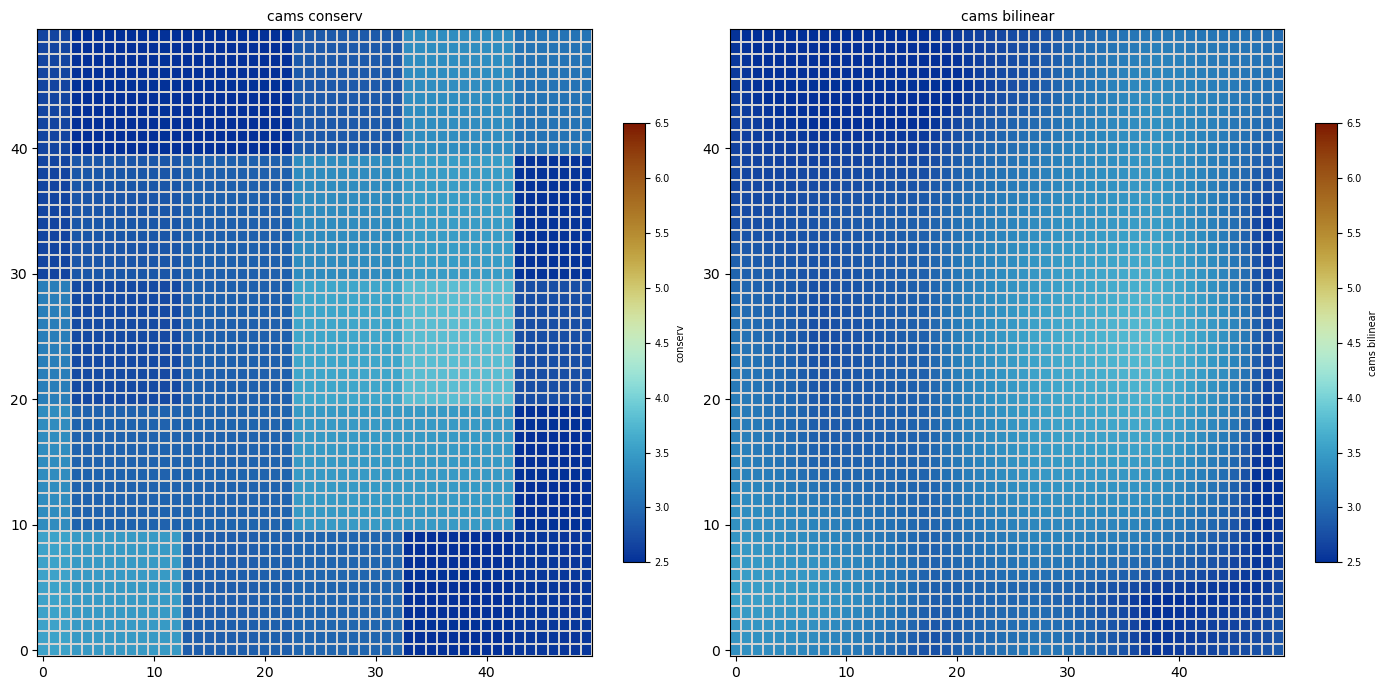

/var/folders/b2/4zv441n11_s6ww9psppcn0s80000gn/T/ipykernel_49503/2364146677.py:214: RuntimeWarning: divide by zero encountered in log10
  x_before, y_before, np.log10(eagrid_before),
/var/folders/b2/4zv441n11_s6ww9psppcn0s80000gn/T/ipykernel_49503/2364146677.py:228: RuntimeWarning: divide by zero encountered in log10
  x, y, np.log10(eagrid_after),


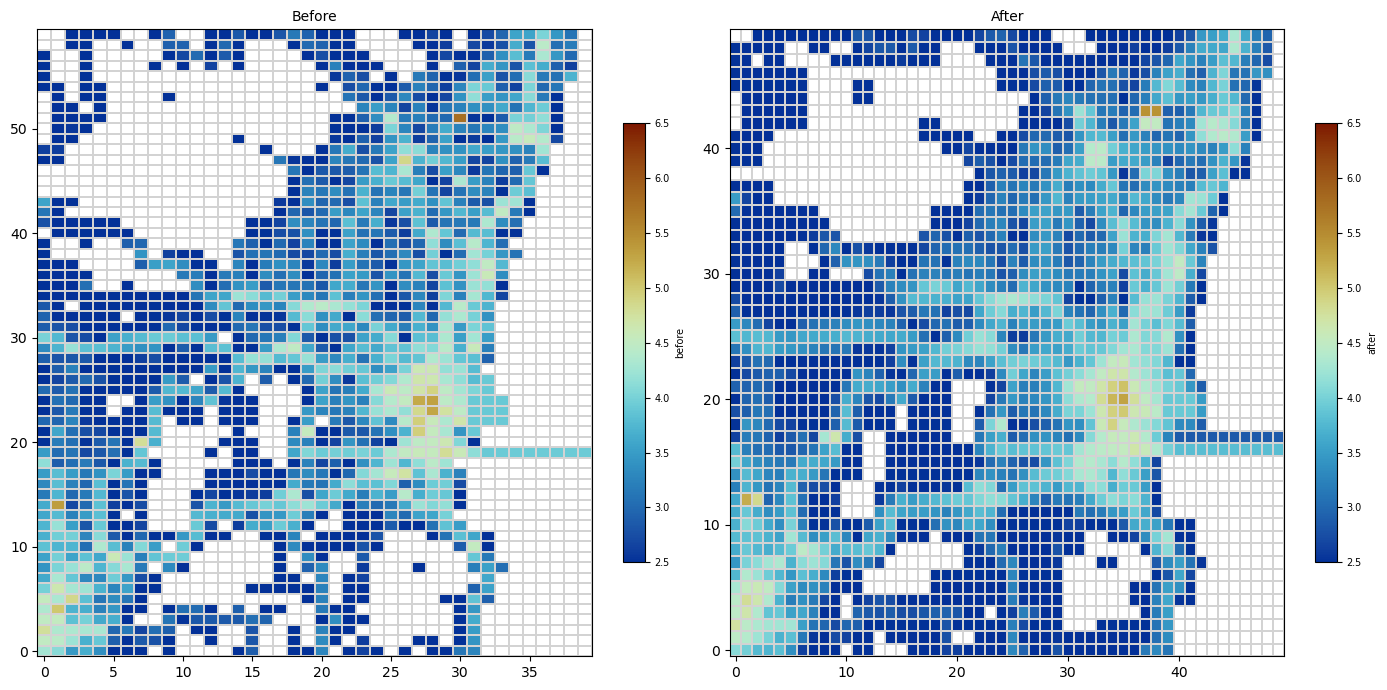

In [90]:
# Tokyo
#center_lon, center_lat = 139.76, 35.68
# Miyazaki
center_lon, center_lat = 131.42, 31.91

# Osaka
#center_lon, center_lat = 135.50, 34.69

# Nagoya
# center_lon, center_lat = 136.91, 35.18

# Sapporo
#center_lon, center_lat = 141.35, 43.06
plot_testdata(center_lon, center_lat)